# Mapping von Institutionen

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
kb = client.query(f"""
                    SELECT 
                        CASE 
                            -- WHEN kb_inst.ror = 'https://ror.org/021ft0n22' THEN 'Universitätsmedizin Göttingen' # in der KB-Kodierung als GAU kodiert
                            WHEN kb_inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                            WHEN kb_inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN kb_inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                            WHEN kb_inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                            WHEN kb_inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/03m2kj587' THEN 'Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                            WHEN kb_inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                            WHEN kb_inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                            WHEN kb_inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                            WHEN kb_inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                            WHEN kb_inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                            WHEN kb_inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                            -- Ergänzung von Suborganisationen (Oldenburg)
                            WHEN inst_id = 445 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 6612 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 316 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 315 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 5488 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 4564 THEN 'Carl von Ossietzky Universität Oldenburg'
                            ELSE ''
                        END AS parent_name,
                        CASE 
                            -- Ergänzung von Suborganisationen (Oldenburg)
                            WHEN inst_id = 445 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 6612 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 316 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 315 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 5488 THEN 'Helmholtz-Institut für Funktionelle Marine Biodiversität'
                            WHEN inst_id = 4564 THEN 'Institute for Science Networking Oldenburg GmbH'
                            ELSE 'not assigned'
                        END AS inst_name,
                        inst.address_full AS raw_affiliation_string,
                        doi
                    FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                    JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                      ON inst.inst_id_top = kb_inst.inst_id
                    JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                        ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                    WHERE oal.type IN ('article', 'review') 
                        AND is_paratext=FALSE 
                        AND is_retracted=FALSE 
                        AND is_xpac=FALSE
                        AND publication_year BETWEEN 2020 AND 2024
                        AND (kb_inst.ror IN (
                            'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                            'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                            'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                            'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                            'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                            'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                            'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                            'https://ror.org/03m2kj587', -- Hochschule Hannover
                            'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                            'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                            'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                            'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                            'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                            'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                            'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                            'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                            'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                            'https://ror.org/04qmmjx98', -- Universität Osnabrück
                            'https://ror.org/059vymd37', -- Hochschule Osnabrück
                            'https://ror.org/045y6d111' -- Universität Vechta
                        ) OR kb_inst.inst_id IN (
                             -- Ergänzung von Suborganisationen (Oldenburg)
                             445, -- 'Evangelisches Krankenhaus Oldenburg'
                             6612, -- 'UMO - Universitätsmedizin Oldenburg'
                             316, -- 'Klinikum Oldenburg gGmbH'
                             315, -- 'Pius-Hospital Oldenburg'
                             5488, -- 'Helmholtz-Institut für Funktionelle Marine Biodiversität an der Universität Oldenburg (HIFMB)'
                             4564 -- Institute for Science Networking Oldenburg GmbH
                            )
                        )
                    ORDER BY inst_name
                    """).to_dataframe()

In [5]:
kb.replace({'Universitätsmedizin Oldenburg': 'Fakultät VI - Medizin und Gesundheitswissenschaften'}, inplace=True)

In [6]:
kb.head()

,parent_name,inst_name,raw_affiliation_string,doi
0,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1111/rec.13398
1,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Inst. for Functional Marine Biodiver...,10.1111/ecog.05869
2,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1111/rec.13398
3,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1111/jeu.13015
4,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Inst. for Functional Marine Biodiver...,10.1111/ecog.05869


In [7]:
CLAUSTHAL_MAPPING = {
    'Clausthaler Umwelttechnik Forschungszentrum (CUTEC)': ['cutec'],
    'Clausthaler Zentrum für Materialtechnik (CZM)': ['(czm)', 'cent(er|re) (for|of) material(s)? technology', 'zentrum für materialtech(nik|nologie)',
                                                     ],
    'Fakultät für Energie- und Wirtschaftswissenschaften': ['mineral', 'geo(-engineering|mechanic)', 'market', 'fuel technology',
                                                            '(sub)?surface energy', 'power engineering', 'geolog(ie|y)', 'economics',
                                                            'thermodynamic', 'verfahrenstechnik', 'betriebswirtschaftslehre',
                                                            'mining', 'geophysi(k|cs)', '(energie|deponie)technik', 'petroleum', 'faculty for energy',
                                                            'economics', 'endlagerforschung', '(geotechnical|energy) engineering',
                                                            'kreislaufwirtschaftssysteme', 'repository', 'electric(al)? power',
                                                            'circular economy', 'digital transformation'
                                                           ], 
    'Fakultät für Mathematik/Informatik und Maschinenbau': ['software (and system|systems engineering)', 'tribology', 
                                                            'chemical', 'metallurgy', 'mathemati(cs|k|cal)',
                                                            'informati(k|cs)', 'disposal', 'particle',
                                                            'welding', 'stochastics', 'anlagentechnik',
                                                            'computer science', '(applied|technical) mechanics',
                                                            'data science', 'continuous optimization',
                                                            'maschinenwesen', 'informationstechnik',
                                                            '(hcis)', 'separation', 'human(-|\s)centered', 
                                                            'electrical information', '(mechanical|plant) engineering',
                                                            'schweißtechnik', 'mechanical', 'isse,', 'isaf,'
                                                           ],
    'Fakultät für Natur- und Materialwissenschaften': ['materials (science|engineering)', 'chemi(e|stry)', 'non(‐|-)?metallic', 
                                                       'metallurgie', 'physical technologies', 'nichtmetallische',
                                                       'theoreti(sche|cal) physi(k|cs)', 'werkstoff(kunde|technik)',
                                                       'polymer', 'energieforschung', 'energy research cent(er|re)'
                                                      ],
    'Forschungszentrum Energiespeichertechnologien': ['energy storage', 'energiespeichertechnologien'],
    #'Geomuseum': [],
    #'LaserAnwendungsCentrum': []
}

In [8]:
EMDEN_MAPPING = {
    'Fachbereich Seefahrt und maritime Wissenschaften': ['maritime (sciences|mobility)', 'nautical'],
    'Fachbereich Soziale Arbeit und Gesundheit': ['so(z|c)ial', 'public health', 'life sciences'],
    'Fachbereich Technik': ['technology', 'engineering', 'laser', 'informatic', 'energies', 'fachbereich technik', 'machine dynamics', 'maschinendynamik',
                            'solar energy', 'mixed reality lab'
                           ],
    'Fachbereich Wirtschaft': ['wirtschaft', 'business', 'finanzmanagement', 'economics']
    # 'Hochschulbibliothek': [''],
}

In [9]:
GAU_MAPPING = {
    'Bernstein Zentrum für Computational Neuroscience Göttingen': ['computational neuroscience', 'bernstein zentrum'], # selbst ergänzt
    'Campus Institut für Dynamik biologischer Netzwerke (CIDBN)': ['biological networks'],
    'Campus-Institut Data Science (CIDAS)': ['cidas', 'campus institute data science'],
    'Centre for Modern Indian Studies (CeMIS)': ['cent(er|re) for modern indian studies'],
    'Center for Integrated Breeding Research (CiBreed)': ['int\w* breeding'], # selbst ergänzt
    #'Courant Forschungszentrum Armut, Ungleichheit und Wachstum in Entwicklungsländern': [],
    #'Courant Forschungszentrum Bildung und Religion': [],
    #'Courant Forschungszentrum Evolution des Sozialverhaltens': [],
    #'Courant Forschungszentrum Nanospektroskopie und Röntgenbildgebung': [],
    #'Courant Forschungszentrum Geobiologie': [],
    #'Courant-Forschungszentrum Textstrukturen': [],
    #'DFG Forschungszentrum für Molekularphysiologie des Gehirns': [],
    #'Erasmus Mundus Programme Euroculture - Society, politics and culture in a global context': [],
    'Fakultät für Agrarwissenschaften': ['landwirtschaftlich', 'agricultural', 'breeding research', 'veterinary', '(animal|crop) (science|plant)', 'mycotoxin',
                                         'agro(ecology|biodiversity|nomy)', 'biogeochemistry', 'plant pathology', 'animal (medicine|hygiene)', 'husbandry',
                                         'agrarökonomie', 'grassland', 'tierärztliches institut', 'agrarökosysteme', 'plant breeding'
                                        ],
    'Fakultät für Biologie und Psychologie': ['biolog(ie|y) (and|und|&) psycholog(ie|y)', 'blumenbach', 'evolution of plants', 'georg-elias', 'conservation biology',
                                              '(department|institute) of psychology', '(animal|human|behavioral) ecology', 'climate dynamics', 'applied bioinformatics',
                                              'cent(er|re) (of|for) molecular biosciences', 'von(-|‐|\s)haller', 'plant cell biology', 'zoology and anthropology',
                                              'enzymology', '(educational|developmental|experimental) psychology', 'plant ecology', 'zelluläre neurobiologie',
                                              'mi(k|c)robiolog(ie|y) (und|and|&amp;) geneti(k|cs)', 'behavioural biology', 'plant biochemistry',
                                              '(socio|neuro)biology', 'psychologie und psychotherapie', 'molecular structural biology', 'biology education',
                                              'psychology of language', 'phycology', '(general|applied) microbiology', 'developmental biology',
                                              'vegetation', '(abteilung|animal) evolution', 'molecular oncology', 'genomic', ' social and communication',
                                              'evolutionary developmental', 'zentrum für molekulare biowissenschaften', 'department of bioinformatics'
                                             ],
    'Fakultät für Chemie': ['(physi(kalische|cal)|(an|in)organi(sche|c)) chemi(e|st(r)?y)', 'biomole(k|c)ular', '(faculty|department) of chemistry', 'w(ö|oe)hler',
                            'sustainable materials and chemistry', 'organic chemistry'
                           ],
    'Fakultät für Forstwissenschaften und Waldökologie': ['centre of biodiversity', 'forest', 'wood', 'biogeography', 'ecosystem modelling',
                                                          'radio(‐|-)?isotopes', '(soil|wildlife) science', 'stable isotope', 'bioclimatology',
                                                          'wildlife', 'forstwissenschaften', 'conservation policy'
                                                         ],
    'Fakultät für Geowissenschaften und Geographie': ['geo(dynamics|science)', 'mineralog(ie|y)', 'geowissenschaftliches zentrum', '(physical|human) geography',
                                                      'sedimentology', 'cartography', '(angewandte|applied|isotope) geolog(ie|y)', 'geoscientific',
                                                      '(department|institute) of geo(biology|graphy)', 'abt(.|eilung) geochemie', 'geographisches'
                                                     ],
    'Fakultät für Mathematik und Informatik': ['computer science', 'mathemati(k|cs|sch)', 'stochastic', 'bernstein‐institute', 'institut(e)? (für|of) informati(k|cs)',
                                               'maschinelles lernen', 'computer security', 'breeding informatics', 'mathematical institute'
                                              ],
    'Fakultät für Physik': ['geophysik', 'complex systems', 'friedrich-hund', 'x(‐|-)ray physics', 'physics—biophysics', 
                            '(institute|fa(k|c)ult(ät|y)|department) (der|für|of) physi(k|cs)', 
                            'physi(kalisches|cal) institut(e)?', 'theoreti(sche|cal) physi(k|cs)', 'materials physics', '(astro|röntgen)physik', 'didaktik der physik',
                            'physics education'
                           ],
    #'Forum für interdisziplinäre Religionsforschung (FiReF)': [],
    'Gesellschaft für wissenschaftliche Datenverarbeitung mbH Göttingen': ['gwdg', 'escience', 'gesellschaft für wissenschaftliche datenverarbeitung'],
    #'Graduiertenschule für Geisteswissenschaften Göttingen (GSGG)': [],
    'Göttinger Graduiertenzentrum für Neurowissenschaften': ['center nanoscale microscopy', 'molecular biosciences'], 
    #'Göttinger Graduiertenzentrum für Neurowissenschaften, Biophysik und Molekulare Biowissenschaften (GGNB)'
    #'Informationsverbund Dermatologischer Kliniken (IVDK)': [],
    #'Interdisziplinäres Zentrum für Nachhaltige Entwicklung': [],
    'Juristische Fakultät': ['(rechts|kriminal)wissenschaften', '(bio|medizin|jugendstraf|landwirtschafts|arbeits|europa|familien)recht', 'faculty of law', 'labour law', 
                             'juristische fakultät'
                            ],
    'Lichtenberg-Kolleg': ['lichtenberg'],
    'Niedersächsische Staats- und Universitätsbibliothek': ['bibliothek', 'library', 'papendiek 14', 'sub göttingen'],
    'Philosophische Fakultät': ['arch(a)?eology', '(früh|neuere)(\s)?geschichte', 'english', 'philo(soph|log(ie|y))', 'sprachwissenschaft', 
                                '(iranian|(east )?asian|romance) studies', 'protohistory', 'romance languages', 'musicol(ogy)?',
                                'cultural anthropology', 'faculty of humanities', '(early|regional|modern) history', '(althistorisches|skandinavisches) seminar'
                               ],
    #'Sonderforschungsbereich 1136': [],
    'Sozialwissenschaftliche Fakultät': ['(institut(e)?|faculty) (für|of) (so(z|c)i|political)', 'sociological research institute', 'democracy (research|studies)',
                                         '(sport(s)?|political|educational) science', '(politik|sport|erziehungs)wissenschaft', 'soziologisches',
                                         'erziehungswissensch'
                                        ],
    'Theologische Fakultät': ['theologische fakultät'],
    'Universitätsmedizin Göttingen (UMG)': ['univ(ersi(t)?((ä|a|ae)ts|y))?(\s|\sof\s)?(med|hosp|klinik)', 'gyn(äk|ec)olog(ie|y)', 'dentistry', 'cardiovascular',
                                            'medical (university )?(cent(re|er)|school|clinic|science)?', 'neuroimmunology', 'cardiology', 'psychosomatic',
                                            'h((a)?e|ä)matolog(ie|y)', 'radiolog(ie|y)', 'neurology', 'medical (bio)?informatics', 'pneumology', 'augenklinik',
                                            'pharmacology', 'an(a)?esthesiology', 'bioimaging', 'psychiatry', 'psychoneuroscience', 'dental', 'anatomy',
                                            'heart cent(er|re)', 'palliativmedizin', 'cellular biophysics', 'medizinische statistik', 'nephrology',
                                            'infektiologie', '(trauma|neuro|thoracic|neck)(\s)?surgery', 'epidemiology', 'medizin und psychotherapie',
                                            'otorhinolaryngology', 'maxillofacial', 'jugendpsychiatrie', 'molecular cell', 'gastroenterolog(ie|y)',
                                            'otolaryngology', '889', '1690', '1286', 'faculty of medicine', 'department of dermatology',
                                            'nuclear medicine', 'orthop(a)?edics', '(gesichts|unfall)chirurgie', 'hno(\s|-)(klinik|göttingen)',
                                            'cellular biochemistry', 'forensisch', 'geriatrics', 'frauenheilkunde', "children's hospital",
                                            'klinik für psychiatrie', 'neuropathology', 'pediatrics', 'clinical psychology', 'ophthalmol',
                                            'cardiovasc'
                                           ],
    'Wirtschaftswissenschaftliche Fakultät': ['econometrics', 'innovation', 'department of economics', 'economic (sciences|policy)', 'business and economics',
                                              'business (education|administration|economics)', 'logistics', '(professur|chair) (für|of) statisti(k|cs)',
                                              'information(s|\s)(management|systems)', 'anwendungssysteme', 'application systems', 'sozialgeschichte',
                                              '(development|public) economics', 'rechnungslegung', 'wirtschaftspädagogik', 'management and control', 
                                              'information security', 'volkswirtschaftslehre'
                                             ],
    #'Zentrale Kustodie': [],
    #'Zentrum für Antike und Orient': [],
    'Zentrum für Biodiversität und Nachhaltige Landnutzung': ['cent(er|re) (for|of) (biodiversity|sustainable)'],
    #'Zentrum für empirische Unterrichts- und Schulforschung (ZeUS)': [],
    #'Zentrum für Globale Migrationsstudien (CeMig)': [],
    'Zentrum für Statistik': ['zentrum für statistik'],
    #'ZESS - Zentrale Einrichtung für Sprachen und Schlüsselqualifikationen': []
}

In [10]:
HAWK_MAPPING = {
    #'HAWK plus Entrepreneurship': [],
    'Fakultät Ingenieurwissenschaften und Gesundheit': ['plasma', 'eng(.|n|ine(e)?ring) (and|&) h(ea)?lth', 'ingenieurwissenschaften und gesundheit',
                                                        'sciences and technology', 'fluidmechanics', '(health |gesundheits)campus', 'faculty of science and art'
                                                       ],
    'Fakultät Ressourcenmanagement': ['resource mana(na)?gement', 'faculty of management', 'fakultät management', 'ressourcenmanagement'],
    'Fakultät Bauen und Erhalten': ['architecture', 'bauen und erhalten'],
    'Fakultät Gestaltung': ['design', 'gestaltung'],
    'Fakultät soziale Arbeit und Gesundheit': ['soziale arbeit', 'social work'],
    #'Fakultät Management, Soziale Arbeit, Bauen': []
}

In [11]:
HBK_MAPPING = {
    'Institut für Designforschung (IDF)': ['designforschung'],
    #'Institut für Kunstwissenschaft (IKW)': [],
    #'Institut für Medienwissenschaft (IMW)': [],
    #'Institut Performative Praxis, Kunst und Bildung (IPKB)': []
}

In [12]:
HILDESHEIM_MAPPING = {
    'Center for World Music (CWM)': ['center for world music'],
    'Centrum für Lehrerbildung und Bildungsforschung (CeLeB)': ['lehrerbildung'],
    'Fachbereich I: Erziehungs- und Sozialwissenschaften': ['education(al)? science', 'psycholog(ie|y)', 'sport', 'erziehungswissenschaft',
                                                            'so(z|c)ial', 'grundschuldidaktik', 'theologie', 'geschichte', '(institute|faculty) of education',
                                                            'psychopathology', 'migration', 'economics education', 'research methods'
                                                           ],
    'Fachbereich II: Kulturwissenschaften und Ästhetische Kommunikation': ['english', 'philosoph(ie|y)', 'kulturpolitik', 'musikwissenschaft',
                                                                           'cultural policy'
                                                                          ],
    'Fachbereich III: Sprach- und Informationswissenschaften': ['language (science|processing)', 'linguistics', 'deutsche sprache', 'informationswissenschaften',
                                                                'sprachtechnologie', 'information science', 'inter(k|c)ultur(elle|al)',
                                                                'übersetzungswissenschaft', 'german language',
                                                               ],
    'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik': ['institut für informatik', 'ecology', 'machine learning',
                                                                                   'biolog(ie|y)', 'angewandte informatik', 'business administration',
                                                                                   'mat(h)?emati(k|cs)', 'geography', 'information systems',
                                                                                   'computer science', 'software systems engineering', 'wirtschaftsinformatik',
                                                                                   'data analytics', 'ismll,'
                                                                                  ],
    #'Universitätsbibliothek': [],
    #'Zentrum für Geschlechterforschung': []
}

In [13]:
HMTMH_MAPPING = {
    #'Europäisches Zentrum für Jüdische Musik (EZJM)': [],
    #'Fachbereich Musiktheorie': [],
    #'Forschungszentrum Musik und Gender': [],
    #'Institut für Alte Musik': [],
    'Institut für Journalistik und Kommunikationsforschung': ['journalism', 'journalistik', 'kommunikationsforschung',
                                                              'communication research'
                                                             ],
    #'Institut für Kammermusik': [],
    'Institut für Musikphysiologie und Musikermedizin': ['physiology', 'musikphysiologie'],
    'Institut für Musikpädagogische Forschung': ['music education research'],
    #'Institut für Neue Musik': [],
    'Institut zur Früh-Förderung musikalisch Hochbegabter': ['music lab'],
    'Musikwissenschaftliches Institut': ['musicology', 'musikwissenschaftliches'],
    #'Popinstitut Hannover': [],
    #'Studienzentrum Weltmusik': []
}

In [14]:
HSH_MAPPING = {
    'Fakultät I - Elektro- und Informationstechnik': ['informationstechnik', 'electrical', 'sensor'],
    'Fakultät II - Maschinenbau und Bioverfahrenstechnik': ['ricklinger', 'bioprocess', 'mechanical engineering', 'microbiology', 'bioplastics',
                                                            'mechatronics', 'verfahrenstechnik', 'faculty ii,'
                                                           ],
    'Fakultät III - Medien, Information und Design': ['expo plaza', 'design and media', 'fa(k|c)ult(at|y|ät) iii', 'information and communication',
                                                      'design'
                                                     ],
    'Fakultät IV - Wirtschaft und Informatik': ['computer science', 'faculty iv'],
    'Fakultät V - Diakonie, Gesundheit und Soziales': ['soziale arbeit', 'social work', 'blumhardtstraße', 'diakonie', 'nursing', 'health'],
    'Institute for Applied Data Science Hannover (Data|H)': ['data(\|)?h', 'applied data science']
}

In [15]:
HSOSNABRÜCK_MAPPING = {
    #'Department für Duale Studiengänge (DDS)': [],
    'Fakultät Management, Kultur und Technik': ['faculty of management', '(management|kultur) (und|and) (techn(ik|ology)|kultur)'],
    #'Institut für Kommunikationsmanagement': [],
    #'Institut für Theaterpädagogik': [],
    'Fakultät Agrarwissenschaften und Landschaftsarchitektur': ['agrarwissenschaften', 'agricultur(e|al)', 'horticultural', 'poultry', 'pflanzenschutz', 'ecology',
                                                                'nutrition', 'plant breeding', 'pflanzenernährung', 'landwirtschaftlich', 'tierhaltung'
                                                               ],
    'Fakultät Ingenieurwissenschaften und Informatik': ['computer (science|engineering)', 'material(s)? design', 'ingenieurwissenschaften', 'chemistry',
                                                        'verfahrenstechnik', 'thermodynamik', 'plastics'
                                                       ],
    'Fakultät Wirtschafts- und Sozialwissenschaften': ['social (science|studies)', 'sozialwissenschaft(t)?en', 'economic sciences'],
    #'Forschungszentrum Energiewirtschaft Energierecht (FEE)': [],
    'Forschungszentrum für Gesundheits- und Sozialinformatik': ['health informatics', 'social informatics'], # selbst ergänzt
    #'Institut für Musik': [],
    #'Kompetenzzentrum Globale Kompetenz': []
}

In [16]:
JADE_MAPPING = {
    'Fachbereich Seefahrt und Logistik': ['maritime', 'marine', 'seefahrt'],
    #'Fachbereich Architektur': [],
    'Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie': ['geoinformat(ion|ics)', 
                                                                     'audiolog(ie|y)', 'civil', 
                                                                     'hearing technology', 'geoinformati(k|c)',
                                                                     'assistance systems', 'assistive',
                                                                     'acoustics', 'gesundheit',
                                                                     'architecture', 'pflegewissenschaft',
                                                                     'technology and health'],
    'Fachbereich Ingenieurwissenschaften': ['dep(.|t.|ar(t)?ment) of engineering', 'engineering department', 'ingenieurwissenschaften',
                                            'verfahrenstechnik', 'mechatronic systems', 'production and industrial'
                                           ],
    'Fachbereich Management': ['management, information(,| and) technolog(ie|y)'],
    'Fachbereich Wirtschaft': ['wirtschaft und gesellschaft']
}

In [17]:
LEIBNIZ_MAPPING = {
    'Exzellenzcluster PhoenixD': ['phoenixd'],
    'Fakultät für Architektur und Landschaft': ['environmental planning', 'archite(c|k)tur', 'raumentwicklung', 'umweltplanung',
                                                'sustainable building systems', 'urban design'
                                               ],
    'Fakultät für Bauingenieurwesen und Geodäsie': ['baustoff', '(civil|coastal|digital) engineering', 'erdmessung',
                                                    'wind energy', 'risk( and| &|,) reliability', 'geodesy',
                                                    'cartography', 'geo(information|technical)', 'numerische mechanik',
                                                    'steel', 'geodetic', 'concrete', 'communications', 
                                                    '(computational|numerical) mechanics', 'waste', 'massivbau',
                                                    'bauphysik', 'building (physics|materials)', 'hydrology', 'bauwesen',
                                                    'statik und dynamik', 'risiko und zuverlässigkeit,', 'geoinformatik'
                                                   ],
    'Fakultät für Elektrotechnik und Informatik': ['drive systems', 'mic(ro|or)wave', '(electrical|software|systems) engineering',
                                                   'microelectronic', 'electric power', 'knowledge(-|\s)based',
                                                   'information (processing|systems)', 'devices', 'electrotechnology',
                                                   'computer science', 'artificial', 'informationsverarbeitung',
                                                   'regelungstechnik', 'of eecs', 'human(-|\s)computer(-|\s)interaction',
                                                   'microeletronic', 'data science', '(theoretische|praktische) informatik',
                                                   'power electronics', 'software systems', 'power systems',
                                                   'sensors and measurement', 'elektrotechnik', 'communication technology',
                                                   'kommunikationstechnik', 'health informatics', 'electrical energy',
                                                   'schering', 'appels(t)?r. 9a', 'antriebssysteme', 'natural language processing'
                                                  ],
    'Fakultät für Maschinenbau': ['i(fw|wf)', 'thermo', 'continuum', 'assembly', 'plastic', 'turbomachinery', 'tribology',
                                  'forming', 'product(ion)? (technology|engineering|development)', 'mechatronic systems', 'werkstoffkunde',
                                  'transport', 'automatic control', 'multiphase processes', 'fabrikanlagen', 'institute of materials',
                                  'umformtechnik', 'reactive flows', 'vibration', 'technische verbrennung', 'kontinuumsmechanik',
                                  'mikroproduktionstechnik', '(mechanical|plant) engineering', 'werkzeugmaschinen', 'for material(s)? science',
                                  'berufswissenschaften der metalltechnik', 'combustion', 'mechantronic systems', 'produktentwicklung'
                                 ],
    'Fakultät für Mathematik und Physik': ['(applied|angewandte) math', 'institut(e)? (of|für) photoni(cs|k)', '(cherh)',
                                           '(theoretische|theoretical) physi(k|c)', 'quantum\s?optics', 
                                           'solid(‐|\s|-)state physi(s)?cs', 'gravitation(s|al)\s?physi(k|cs)',
                                           'geometry', 'department of mathematics', 'structural analysis',
                                           'differentialgeometrie', 'quantenoptik', 'algebra', 'festkörperphysik', 'solar',
                                           'meteorolog(ie|y)', 'institut(e)? (für|of) analysis', '(fakultät|faculty) (für|of) mathemati(k|cs)',
                                           'radiation', 'radioökologie', 'financial mathematics', 'computational science', 'mathematik und physik'
                                          ],
    'Forschungsstelle für Gesundheitsökonomie': ['center for health'],
    'Forschungszentrum Küste (FZK)': ['coastal research cent(er|re)', 'forschungszentrum küste'],
    'Forschungszentrum L3S': ['l3s'],
    'Hannoversches Zentrum für Optische Technologien (HOT)': ['hannover centre for optical technologies', 'optical'],
    'House of Insurance (HoI)': ['house of insurance'],
    'Juristische Fakultät': ['institute for political', 'intellectual', 'faculty of law', 'rechtsinformatik'],
    'Laboratorium für Nano- und Quantenengineering (LNQE)': ['nano(-|‐)? and quantum', '(lnqe)', 'quantenengineering', 'schneiderberg 39'],
    #'Leibniz Forschungszentrum FZ:GEO': [],
    #'Leibniz Forschungszentrum Inclusive Citizenship (CINC)': [],
    'Leibniz Forschungszentrum Wissenschaft und Gesellschaft (LCSS)': ['(lcss)'],
    #'Leibniz School of Education': [],
    #'Leibniz School of Optics & Photonics': [],
    #'LiFE 2050 - Leibniz Forschungszentrum Energie 2050': [],
    #'Mechatronik-Zentrum Hannover (MZH)': [],
    'Naturwissenschaftliche Fakultät': ['cell', 'earth', 'production systems', '(food|organic|technical|coordination|theoretical) chemistry', 'inorganic', 'electrochemistry',
                                        'plant genetics', 'nutrition', 'erdsystemwissenschaften', 'botany', '((un)?organische|technische|theoretische) chemie',
                                        'naturwissenschaften', 'soil', 'landscape ecology', 'elektrochemie', 'microbiology', 'food and one health',
                                        'geography', 'department of chemistry', 'lebensmittel(wissenschaft|chemie)', 'gartenbau', 'geolog(ie|y)', 'mineralog(ie|y)',
                                        'natural sciences', 'geophysics', 'science education', 'koordinationschemie', '(physical|medicinal) chemistry',
                                        'biostatistics', 'am kleinen felde 30', 'naturwissenschaftliche fakultät', 'kulturgeographie',
                                        'plant genetic'
                                       ],
    'Philosophische Fakultät': ['institute of philosophy', 'so(c|z)iolog(ie|y)', '(historisches|deutsches) seminar', 'humanities', 
                                'language therapy', 'of political science' , 'life sciences', 'psychology', 'sonderpädagogik',
                                'institute of education', 'sportwissenschaft', 'sport(s)? science', 'special education',
                                'quest', 'historical institute', 'theologie', 'linguistics', 'philosoph(ie|y)', 'ethics and law',
                                'didaktik der demokratie', 'english', 'adult education', 'department of history', 'religion'
                               ],
    #'QUEST-Leibniz-Forschungsschule': [],
    #'TRUST Räumliche Transformation - Zukunft für Stadt und Land': [],
    'Wirtschaftswissenschaftliche Fakultät': ['wirtschaftsinformatik', 'taxation', 'world trade', 'institute of health',
                                              'marketing', 'banking', 'institute of statistics', 'economics (and management|department)',
                                              'labour economics', 'human resource management', 'finanzmathematik', 'agricultural',
                                              'welthandel', 'risk and insurance', 'macroeconomic', 'economic policy', 'for health economics',
                                              'employment studies', 'managerial accounting', 'institute of economics', 'innovation research',
                                              'wirtschaftswissenschaftliche', 'production management', 'produktionswirtschaft', 
                                              'versicherungsbetriebslehre', 'arbeitswissenschaft', 'institut für statistik'
                                             ],
    'Zentrum für Biomolekulare Wirkstoffe (BMWZ)': ['biomolecular'],
    #'Zentrum für Festkörperchemie und Neue Materialien (ZFM)': [],
    #'Zentrum für Gartenkunst und Landschaftsarchitektur': [],
    #'Zentrum für Hochschulsport': []
}

In [18]:
LEUPHANA_MAPPING = {
    'DFG-Kollegforschergruppe Medienkulturen der Computersimulation (mecs)': ['media cultures', 'mecs,'],
    'Fakultät Bildung': ['sport', 'psychology', 'theologie', 'education', 'english', 'dida(c|k)ti(c|k)', 'fakultät bildung', 'institut für psychologie',
                         'bildungswissenschaft', 'social work', 'sozialarbeit', 'digital teaching', 'schulpädagogik', 'mathematics', 'social sciences'
                        ],
    'Fakultät Kulturwissenschaften': ['(isco)', 'sociology', 'philosophy', 'kulturorganisation', 'culture and aesthetics', 'geschichtswissenschaft',
                                      'ästhetik', 'kunstwissenschaft', 'cultural management', 'icam,'
                                     ],
    'Fakultät Management und Technologie': ['management (&|and|und|&amp;) organi(z|s)ation', 
                                            'process', 'production', 'information', 
                                            '(sesi)', 'accounting', 'social‐ecological', 'Social(‐|-)Ecological',
                                            'explainability', 'produktionstechnik', 'performance', 'product technology',
                                            'banking', 'innovation', 'business and economics', '(faculty|school) of management (and|&amp;|&) technology',
                                            'department of management', 'wirtschaftsinformatik', 'machine learning', 'digital transformation',
                                            'administration', 'control and drive systems'
                                           ],
    'Fakultät Nachhaltigkeit': ['sustainability', 'ecolog(y|ical)', 'chemistry', 'nachhaltigkeit', 'chemie', 'environmental communication',
                                'energy law', 'ethics', 'sustainable development', 'umweltrecht', 'nachhaltige entwicklung',
                                'insugo,', 'isec,', 'energy economics'
                               ],
    'Fakultät Staatswissenschaften': ['politikwissenschaft', 'institute (of|for) economics', 'political science', 'volkswirtschaft(s)?lehre',
                                      'political culture', 'public affairs'
                                     ],
    #'Forschungszentrum Futures of Ecosystem Services (FuturES)': [],
    'Methodenzentrum': ['cent(er|re) (of|for) methods'],
    #'Research Center for Entrepreneurship (RCE)': [],
    #'Zentraleinrichtung Sprachenzentrum': [],
    'Zentrum Digitale Kulturen (CDC)': ['Digital Cultures'],
    'Zentrum für Angewandte Gesundheitswissenschaften (ZAG)': ['health', 'gesundheitswissenschaften'],
    'Zentrum für Demokratieforschung (ZDEMO)': ['demokratieforschung', 'democracy'],
    #'Zentrum für Empirische Forschung zu Sprache und Bildung (ERLE)': [],
    'Zukunftszentrum Lehrerbildung': ['lehr(er|kräfte)bildung', 'competencies for digitally-enhanced']
}

In [19]:
MHH_MAPPING = {
    'Exzellenzcluster RESIST': ['resist'],
    'Forschungs- und Lehreinheit Hebammenwissenschaft': ['hebammenwissenschaft', 'midwifery'],
    'Hannover Biomedical Research School': ['biomedical research'],
    'Hannover Unified Biobank (HUB)': ['biobank'],
    'Institut für Allgemeinmedizin und Palliativmedizin': ['palliativ', 'allgemeinmedizin', 'general practice'],
    'Institut für Molekulare Bakteriologie': ['bacteriology'],
    'Institut für Molekulare und Translationale Therapiestrategien': ['therapeutic strategies'],
    'Institut für Sportmedizin': ['sport(s)? medicine'],
    'Institut für Transplantationsimmunologie': ['transplant(ation)? immunology'],
    'Institut für Zelltherapeutika': ['(ctc)', 'cellular therapeutics'],
    #'Integriertes Forschungs- und Behandlungszentrum Transplantation (IFB-Tx)': [],
    #'Interdisziplinäres Zentrum für Gesichtsfehlbildungen': [],
    'Klinik für Anästhesiologie und Intensivmedizin': ['an(e|ae|ä)sthesiolog(ie|y)', 'intensivmedizin'],
    'Klinik für Dermatologie, Allergologie und Venerologie': ['dermatolog(ie|y)', 'allergy'],
    'Klinik für Frauenheilkunde und Geburtshilfe': ['obstetrics', 'rehabilitati(ve|on)', 'gyn(ae|e|ä)(k|c)olog(ie|y|ist)', 'frauenheilkunde'],
    #'Klinik für Rehabilitationsmedizin': [],
    #'Kopf-Hals-Tumorzentrum Hannover': [],
    'Leibniz Forschungslaboratorien für Biotechnologie und künstliche Organe (LEBAO)': ['(lebao)'],
    'REBIRTH - Forschungszentrum für translationale regenerative Medizin': ['regenerative', 'rebirth( excellence )?cluster'],
    'Research Core Unit for Laser Microscopy': ['laser microscopy'],
    'Twincore': ['twincore'], # selbst ergänzt
    'Zentralapotheke': ['apotheke'],
    'Zentrale Forschungseinrichtung Elektronenmikroskopie': ['electron microscopy'],
    'Zentrale Forschungseinrichtung Genomics': ['genomics'],
    #'Zentrale Forschungswerkstätten': [],
    'Zentrum Anatomie und Zellbiologie': ['applied anatomy', 'neuroanatomy'],
    'Zentrum Augenheilkunde, Hals-Nasen-Ohrenheilkunde, Phoniatrie und Pädaudiologie': ['otorhinolaryngology', 'otol(ogy|ar(yn|ny)gology)', 
                                                                                        'hals(-)?(, )?nasen', 'ophthalmology', 'hno-(klinik|heilkunde)',
                                                                                        'augen(klinik|heilkunde)', 'eye hospital'
                                                                                       ],
    'Zentrum Biochemie': ['(cell|clinical) biochemistry', 'biophysical chemistry', 'zellbiochemie'],
    'Zentrum Biometrie, Medizinische Informatik und Medizintechnik': ['informatics', 'biostatistics'],
    'Zentrum Chirurgie': ['of urology', 'vas(cu|uc)lar', 'plasti(sch|c)', 'trauma', 'orthop(ae|e)dic', 'orthopädische klinik', 'unfallchirurgi(e|sche)',
                          'visceral', 'surgical', 'viszeral', 'thorax', 'kinderchirurgie', 'biomechanics', 'klinik für urologie',
                          'department of surgery'
                         ],
    #'Zentrum für Arzneimittelsicherheit (ZAS)': [],
    'Zentrum für Kinderheilkunde und Jugendmedizin': ['respiratory', 'pulmon(ology|ary)', 'metabolic', 'p(ae|e|ä)diatri(c|sche)', 'pneumolog(ie|y)',
                                                      'cardiothoracic surgery', 'kinderklinik', "children('|’)s hospital", 'kinderheilkunde'
                                                     ],
    'Zentrum für Klinische Studien (ZKS)': ['(zks)', 'cent(re|er) for clinical trials', 'clinical trial center'],
    'Zentrum für Neurologische Medizin': ['neurolog(ie|y)', 'neurosurgery'],
    'Zentrum für Pathologie, Forensik und Genetik': ['patholog(ie|y)', 'human genetics', 'humangenetik', 'rechtsmedizin', 'legal medicine'],
    'Zentrum für Pharmakologie und Toxikologie': ['toxicology', 'pharma(k|c)olog(ie|y)', 'metabolomics'],
    'Zentrum für Radiologie': ['radiolog(ie|y)', 'radiotherapy', 'nuclear', 'radiation', 'strahlentherapie', 'nuklearmedizin'],
    'Zentrum für Seelische Gesundheit': ['psychiatr(ie|y)', 'psychosomati(k|c)', 'psychotherapy', 'neuroscience'],
    'Zentrum für Zahn-, Mund- und Kieferheilkunde': ['dentistry', 'maxillofacial', 'zahnerhaltung', 'gesichtschirurgie'],
    'Zentrum Innere Medizin': ['h(ä|e|ae)matolog(ie|y)', 'hepatolog(ie|y)', 'angiolog(ie|y)', 'rheumatolog(ie|y)', 'hochdruckerkrankungen', 
                               'hypertension', 'gastroenterology', 'nephrology', 'cardiology dept', 'department of cardiology', 'systemerkrankungen',
                              ],
    'Zentrum Laboratoriumsmedizin': ['virology', '(for|of) immunology', 'molecular biology', 'animal', 'transfusion medicine',
                                     'clinical chemistry', 'immunomorphology', 'versuchstierkunde', 'medical microbiology'
                                    ],
    'Zentrum Physiologie': ['neurophysiology', 'cell physiology'],
    'Zentrum Öffentliche Gesundheitspflege': ['philosoph(ie|y)', 'epidemiolog(ie|y)', 'so(z|c)iolog(ie|y)', 'social medicine', 'medical psychology',
                                              'public health', 'medizinische psychologie' 
                                             ]
}

In [20]:
OLDENBURG_MAPPING = {
    'Bibliotheks- und Informationssystem (BIS)': ['informationssystem'],
    'Center für lebenslanges Lernen (C3L)': ['lifelong learning', 'center für lebenslanges lernen'],
    #'CMC - Center for Migration, Education and Cultural Studies': [],
    'COAST - Zentrum für Umwelt- und Nachhaltigkeitsforschung': ['sustainability research', 'coast-zentrum'],
    #'ecco-ecology + communication Unternehmensberatung GmbH': [],
    'Fakultät I - Bildungs- und Sozialwissenschaften': ['(department|institute) (for|of) social science', '(school|institute|faculty|department) of education(al)?', 
                                                        'educational science', 'special (education|needs)', 'lernforschung',
                                                        'rehabilitation', 'research on learning', 'pedagogy', 'schooling', 
                                                        '(open|political|continuing) (education|theory)', 'department i educational',
                                                        'sozialwissenschaft(liche|en)', 'päd(a)?gogik', 'social sciences institute'
                                                       ],
    'Fakultät II - Informatik, Wirtschafts- und Rechtswissenschaften': ['(business|energy) (informati(on|cs)|application|administration)', 
                                                                        'applied artific(i)?al intelligence', 'information technology',
                                                                        'digitalized', '(department|fachbereich|media)( of| für)? (economics|informati(k|cs)|business)', 
                                                                        'comput(er|ing) science', 'offis', 'sustainable information', 'economic(s and)? law', 
                                                                        'resilience learning', 'vwl', 'marketing', 'safety-security',
                                                                        'interconnected systems', '(public|ecological) economics', 'wirtschaftspädagogik', 'micro(-)?robotics',
                                                                        'rechtswissenschaften', 'finance and banking', 'medieninformatik', 
                                                                        'software engineering', 'accounting', 'innovation', 'formale sprachen', 
                                                                        'informatics (department|education)', 'embedded hardware', 'computational intelligence', 
                                                                        'safety and explainability', 'betriebswirtschaft'
                                                                       ],
    'Fakultät III - Sprach- und Kulturwissenschaften': ['sport(s)? science', '(institut(e)?|department) (of|für) musi(k|c)', 'kulturwissenschaften',
                                                        'department of (german|dutch)', 'visuelle kultur', '(german|american|slavic|dutch) studies',
                                                        'musicology', 'linguistics', '(niederland|slaw|german)istik', 'slavic department', 'speech and music lab'
                                                       ],
    'Fakultät IV - Human- und Gesellschaftswissenschaften': ['philosoph(ie|y)', 'department of history', 'religionspädagogik', 'institut für geschichte',
                                                             'so(z|c)iolog(ie|y)', 'historisches institut', 'school iv', 'institute of history',
                                                             'theolog(ie|y)', 'sportwissenschaft', 'fak. iv'
                                                            ],
    'Fakultät V - Mathematik und Naturwissenschaften': ['(icbm)', 'chemi(e|stry) (und|and) biolog(ie|y)', 'industrial chemistry',
                                                        '(ins(t)?(i)?tut(e)?|department|school) (of|f(ü|u|ue)?r|at|for) (ch(e)?mi(e|stry)|physi(k|cs)|biolog(ie|y))', 
                                                        'biodiversit', 'animal navigation', 'biologie Und umweltwissenschaften',
                                                        '(environmental|natural) science', 'nanoscale', 'mathemati(k|cs|sches)', '(geo|bio)(chemistry|diversity)', 
                                                        'dida(k|c)ti(k|cs) (der|of) (chemi(e|stry)|physi(k|cs))',
                                                        '(physics|chemistry) department', 'sustainable energy', '(landscape|aquatic) ecology', 'geology', 
                                                        '(angewandte|technische|applied|physical|theoretical|organische|marine) chemi(e|stry)', 
                                                        'chemical engineering', 'ecology of plants', 'theoretical physic', 'gewässerökologie',
                                                        'evolutionsbiologie', 'marine sensor(ik|s)', 'genomics', 'evolutionary biology', '(plant|functional) ecology',
                                                        '(chemistry|physics) education', 'soil sci.'
                                                       ],
    'Fakultät VI - Medizin und Gesundheitswissenschaften': ['neuro(science|surgery|log(ie|y)|imaging)', 'anatom(ie|y)', 'health(\s)?(service|science|care)', 
                                                            'department of psychology', 'microbiology', 'gastroenterologie', 'laboratory medicine',
                                                            'geriatric', 'dermatology', 'allergologie', 'human medicine', 'gyn(a)?ecology', 'ophthalmology',
                                                            'acoust(.|ics)', 'surgery', 'fa(c|k)ult(ät|y) (6|vi)', 'pulmonology',  'h(ä|e)matolog(ie|y)', 
                                                            'psychiatr(ie|y)', 'machine learning division', 'gastroenterology', 'urology',
                                                            '(medical|medizinischer) (k|c)ampus', 'hearing', 'versorgungsforschung', 'gesundheit',
                                                            'psycholog(ie|y)', 'geneti(k|cs)', 'biometr(ie|y)', 'oncology', 'medizinische (physik|informatik)', 
                                                            'toxicology', 'clinical diagnostics', 'public health', 'medizintechnik',
                                                            'ernährung und funktionalität', 'medical device', 'cardiology', 'big data in medicine',
                                                            'klinikum oldenburg', 'intensivmedizin', 'psychosomatik', 'pediatrics', 'pius', 'klinische chemie',
                                                            'ohrenheilkunde', 'psychological methods', 'signal processing', 'space environment',
                                                            'universit(y|äts)(\s)?(klinik|medi(c|z)in(e)?)', 'immunol(.|ogy)', 'ethics in medicine', 
                                                            'medical (phys(.|ics)|informatics|technolog|radiation)', 
                                                            'ethik in der medizin', 'anesthesiology', 'pädiatrie', 'psychosomatic', 'allgemeinmedizin',
                                                            'radiology', 'otorhinolaryngology', 'emergency', 'ambulante', 'pathologie',
                                                            'hospital', 'general practice', 'ai4health', 'oldenburg clinic'
                                                          ],
    'Forschungszentrum Neurosensorik': ['cent(re|er)( for| of)? neurosensory', 'forschungszentrum( für)? neurosensorik', 'ag ("|‘)(neuro)?sens'],
    'ForWind - Zentrum für Windenergieforschung': ['wind energy', 'forwind'],
    'Hochschulsport': ['sport(s)? cent(re|er)'],
    #'Institute for Science Networking Oldenburg GmbH': [],
    #'Oldenburger Fortbildungszentrum (OFZ)': [],
    #'Zentrum für interdisziplinäre Frauen- und Geschlechterforschung (ZFG)': [],
    #'Zentrum für Lehrkräftebildung - Didaktisches Zentrum (DIZ)': [],
    'Helmholtz-Institut für Funktionelle Marine Biodiversität': ['(hifmb)', 'helmholtz institute'] # selbst ergänzt
}

In [21]:
OSTFALIA_MAPPING = {
    'Fakultät Bau-Wasser-Boden': ['bau-wasser-boden', 'civil engineering', 'enviro(n)?mental engineering', 'civil department'],
    'Fakultät Handel und Soziale Arbeit': ['trade and social work'],
    'Fakultät Verkehr-Sport-Tourismus-Medien': ['media management', 'tourism-media', 'public communication', 'regionalforschung'],
    'Fakultät Elektro- und Informationstechnik': ['electrical (engineering|energy|systems)'],
    'Fakultät Informatik': ['information engineering', 'informatik', 'computer science', 'robotics lab', 'distributed systems', 'faculty for( applied)? informatics'],
    'Fakultät Maschinenbau': ['mechatroni(k|cs)', 'mechanical engineering', 'production technolog(y|ies)', 'maschinenbau'],
    'Fakultät Recht': ['economic law', '(bels)'],
    'Fakultät Soziale Arbeit': ['soziale(n)? arbeit', 'social work'],
    'Fakultät Versorgungstechnik': ['biotechnology', 'kommunikationssysteme', 'supply (engineering|technology)'],
    'Fakultät Fahrzeugtechnik': ['recycling', 'vehicle', 'automotive engineering', 'fahrzeugbau'],
    'Fakultät Gesundheitswesen': ['health(\s)?(care|science|service)', 'gesundheit'],
    'Fakultät Wirtschaft': ['fakultät wirtschaft', 'faculty of business', 'business administration']
}

In [22]:
TIHO_MAPPING = {
    'Anatomisches Institut': ['anatomy'],
    #'Arbeitsgruppe Vektor-assoziierte Biodiversität und Infektionen': [],
    'Außenstelle für Epidemiologie': ['epidemiolog(ie|y)'],
    'Fachgebiet Allgemeine Radiologie und Medizinische Physik': ['general radiology', 'department of radiology'],
    #'Gesellschaft für Innovative Veterinärdiagnostik (IVD GmbH)': [],
    #'Hochschulbibliothek': [],
    'Institut für Biochemie': ['bio(chemi(e|stry))'],
    'Institut für Biometrie, Epidemiologie und Informationsverarbeitung': ['biometry'],
    'Institut für Immunologie': ['immunolog(ie|y)'],
    'Institut für Lebensmittelqualität und -sicherheit': ['food quality', 'food safety', 'lebensmittelqualität'],
    'Institut für Lebensmitteltoxikologie und Chemische Analytik': ['food toxicology'],
    'Institut für Mikrobiologie': ['mi(k|c)robiolog(ie|y)'],
    'Institut für Parasitologie': ['parasitolog(ie|y)', 'fish disease'],
    'Institut für Pathologie': ['pharma(k|c)olog(ie|y)', 'patholog(ie|y)'],
    'Institut für Pharmakologie, Toxikologie und Pharmazie': ['neurowissenschaften', 'neuroscience'],
    'Institut für Physiologie und Zellbiologie': ['physiologi(sche|cal) chemi(e|stry)', 'physiolog(ie|y|ical)', 'zellbiologie'],
    'Institut für Reproduktionsbiologie': ['reproductive biology', 'reproduktionsbiologie'],
    'Institut für Terrestrische und Aquatische Wildtierforschung': ['wildtierforschung', 'terrestrial'],
    'Institut für Tierernährung': ['animal nutrition', 'tierernährung'],
    'Institut für Tiergenomik': ['animal genomics'],
    'Institut für Tierhygiene, Tierschutz und Nutztierethologie': ['tierhygiene', 'animal hygiene'],
    'Institut für Tierzucht und Vererbungsforschung': ['animal breeding', 'tierzucht'],
    'Institut für Tierökologie': ['animal ecology', 'ecology and evolution', 'tierökologie'],
    'Institut für Virologie': ['virolog(ie|y)'],
    'Institut für Zoologie': ['zoolog(ie|y)', 'zoologisches institut'],
    'Klinik für Geflügel': ['poultry'],
    'Klinik für Heimtiere, Reptilien, Zier- und Wildvögel': ['reptil(ien|e)'],
    'Klinik für kleine Klauentiere und Forensische Medizin und Ambulatorische Klinik': ['klauentiere', 'forensic', 'clinic for swine'],
    'Klinik für Kleintiere': ['small animal', 'kleintiere', 'neurologie', 'small domestic animals', 'kleintierklinik'],
    'Klinik für Pferde': ['clinic for horses', 'klinik f(ü)?r pferde', 'equine clinic'],
    'Klinik für Rinder': ['clinic for cattle', 'klinik für rinder', 'diseases of cattle', 'cattle clinic'],
    'Lehr- und Forschungsgut Ruthe': ['farm for education( and research ruthe)?', 'forschungsgut ruthe'], #selbst egänzt
    'Reproduktionsmedizinische Einheit der Kliniken': ['biostabilization laboratory', 'reproductive medicine', 'reproduktionsmedizinische'],
    'Research Center for Emerging Infections and Zoonoses (RIZ)': ['zoonos(e|i)s'],
    'Zentrum für E-Learning, Didaktik und Ausbildungsforschung': ['e(-|‐)learning', 'clinical skills lab', 'cent(re|er) for teaching'] #selbst ergänzt
}

In [23]:
TUBRAUNSCHWEIG_MAPPING = {
    'Braunschweig Integrated Centre of Systems Biology (BRICS)': ['(brics)', 'systems biology'],
    'Carl-Friedrich-Gauß-Fakultät': ['reichertz', 'algebra', 'equations', 'differentialgleichungen', '(automotive|information) management', 'numerical mathematics',
                                     'public policy', 'scientific computing', 'soziologie', 'operating systems', 'computer science', 'wirtschaftsinformatik',
                                     'medical informatics', 'mathematical optimization', 'graphi(k|cs)', 'roboti(k|cs)', 'stochasti(k|cs)', 'application security',
                                     'industrial production', 'numerical', 'finance', 'economics', 'enterprise', '(department|institute) of mathematics', 'communication science',
                                     'international(e)? (relations|beziehungen)', 'sociology', 'dienstleistungsmanagement', 'information systems', 'software engineering',
                                     'unternehmensführung', 'chip design'
                                    ],
    'Carolo-Wilhelmina-Forschungszentren': ['nanometrology', 'carolo-wilhelmina'],
    'Fakultät Architektur, Bauingenieurwesen und Umweltwissenschaften': ['geod(äsie|esy)', 'geo(chemie|technik)', 'wood(-|‐)based (construction|materials)', 'construction (design|management)',
                                                                         '(steel|timber) structures', 'civil engineering', 'geosystems', '(solid|concrete) construction',
                                                                         'water resources', '(wasser|holz|massiv|stahl)bau', 'ecology', 'architecture',
                                                                         'tragwerksentwurf', 'applied mechanics', 'quantenmetrologie', 'urban', 'design research',
                                                                         'data analysis', 'statik', 'materials science', 'geosysteme', '(hydr|metr)ology', 'geoökologie',
                                                                         'hydraulic engineering', 'structural (analysis|design)', 'sanitary', 'railway', 
                                                                         'bau(wirtschaft|werkserhaltung)', 'waste', 'pavement', 'computational (science|mathematics)'
                                                                        ],
    'Fakultät für Elektrotechnik, Informationstechnik, Physik': ['(theoretische|mathematische|angewandte) physik', 'geophysi(k|cs)', 'electromagnetic', 'high voltage',
                                                                 'semiconductor', '(ifn)', 'electrical machines', '(control|network|electrical) engineering',
                                                                 'communication(s)? (technology|network)', 'halbleitertechnik', 'kondensierten materie',
                                                                 'cmos(,| design)', '(applied|theoretical|mathematical|matter) physic(s)?', 'datentechnik',
                                                                 'hochfrequenztechnik', 'elektrotechnik', 'hochspannungstechnik', 'high(-|\s)frequency(\smeas.)? techn(ik|ology)',
                                                                 'nachrichtentechnik', 'photonic', 'emc,', 'information theory' 
                                                                ],
    'Fakultät für Geistes- und Erziehungswissenschaften': ['sport(s)? science', 'fachdidaktik', '(german|american) studies', 'geschichtswissenschaft', 'education',
                                                           'philosophy', 'erziehungswissenschaft', 'bewegungspädagogik', 'germanistik', 'pädagogische',
                                                           'historisches seminar', 'english linguistics', 'sprachwissenschaft'
                                                          ],
    'Fakultät für Lebenswissenschaften': ['pharma', 'neurobiology', 'psychotherap(ie|y)', 'zoological', 'plant biology', '(theoretische|organische|analytische|technische) chemie',
                                          '(institut(e)?|department) (of|f(ü)?r|for|fuer) psycholog(ie|y)', '(physical|analytical|theoretical|technical|organic|sustainable) chemistry', 
                                          'food chemistry', 'bioinformatics', 'mi(k|c)robiolog(ie|y)', 'lebensmittelchemie', 'biotechnolog(ie|y)', 'geneti(k|cs)',
                                          'electrocatalysis', 'social psychology', 'zoologische(s)?', 'klinische psychologie', 'life sciences', 'sociotechnical',
                                          '(engineering|traffic) psychology', '(sozial|verkehrs)psychologie', 'pflanzenbiologie', 'physiology', 'biochemistry'
                                         ],
    'Fakultät für Maschinenbau': ['thermal process', 'turbomachinery', 'dynamics and vibrations', 'werkzeugmaschinen', 'joining', 'machine tools',
                                  'fluid (mechanics|dynamics)', 'aerospace', 'a(k|co)usti(k|cs)', 'aviation', 'particle(s)? technology', '(ines)', 'institut für werkstoffe',
                                  'biochemical engineering', 'process systems engineering', 'engineering design', '(mechanical|automotive) engineering', 'adaptroni(k|cs)',
                                  'logistic(s)? systems', 'aircraft', '(schweiß|partikel)technik', 'mi(k|c)ro(\s)?tech(n)?(ik|ology)', 'battery lab(\s)?factory', 
                                  'flight guidance', 'flugf(ü|u)hrung',
                                  'space systems', 'maschinenbau', '(surface|automotive) technology', 'str(o|ö)mungs(maschinen|mechanik)', 'thermodynami(k|cs)',
                                  '(produktionsmess|konstruktions)techni(c)?k', 'vehicle drives', 'production measurement', 'flugzeugbau', 'thermische verfahrenstechnik',
                                  'dynamik und schwingungen', 'verbrennungskraftmaschinen', '(iprom)', 'intermodal'
                                 ],
    'Niedersächsisches Forschungszentrum Fahrzeugtechnik (NFF)': ['center for automotive'],
    #'Niedersächsisches Forschungszentrum für Luftfahrt (NFL)': [],
    'Universitätsbibliothek': ['universitätsbibliothek'],
    #'Zentrale Einrichtung Botanischer Garten': []
}

In [24]:
UOSNABRÜCK_MAPPING = {
    'Fachbereich Biologie / Chemie': ['dida(c|k)ti(k|cs) (of|der) (biolog(ie|y)|chemie)', 'genetics', 'biolog(ie|y)(/| and )chemi(e|stry)', 'botan(y|ical)', 
                                      '(new|organic|neuer) material(ien|s)', '(neuro|mi(k|c)ro)biolog(ie|y)', 'chemi(e|stry)', 'electrochemical',
                                      'bioorganische', '(behavio(u)?ral|structural|cell) biology', 'nanoanalytic', 'zoology', 
                                      'plant physiology', 'ecology', 'animal', '(department|faculty) of biology', 'bioimaging'
                                     ],
    'Fachbereich Erziehungs- und Kulturwissenschaften': ['education(al)? science', 'erziehungswissenschaft', '(school|science) of education', 
                                                         '(islami(sche|c)|katholische|ev.|evangelische) theolog(ie|y)', 'vocational',
                                                         'schulpädagogik', 'sport', 'elementary education', 'childhood', 
                                                        ],
    'Fachbereich Humanwissenschaften': ['kognitionswissenschaft', 'dermatolog(ie|ic|y|ische)', 'psycholog(ie|y)', 'cognitive', '(human|health) (sciences|research)',
                                        'pflegewissenschaft', 'philosophy', 'ethics and critical theories', 'new public health', 'psychotherapy',
                                        'gesundheitsforschung'
                                       ],
    'Fachbereich Kultur- und Sozialwissenschaften': ['social sciences', 'geograph(ie|y)', 'sozial(- und kultur)?wissenschaften', 'european integration',
                                                     'music', 'conflict research', 'historisches seminar', 'department of history', 'modern history',
                                                     'neueste geschichte'
                                                    ],
    'Fachbereich Mathematik / Informatik / Physik': ['mathemati(k|cs)', '(institut|department) (für|of) (physi(k|cs)|informatik)', 'computer science', 'physi(k|cs),',
                                                     'semantic information', 'data science', 'information systems', 'digital image', 'fachbereich physik',
                                                     'software engineering', 'physics (education|department)', 'computer engineering', 'knowledge-based systems',
                                                     'artificial intelligence'
                                                    ],
    'Fachbereich Rechtswissenschaften': ['(gesellschafts|straf|völker|europa|wirtschafts)recht', 'faculty of law', 'legal studies'],
    'Fachbereich Sprach- und Literaturwissenschaft': ['germanistik', 'linguistics', 'american studies', 'latinistics', 'romance studies'],
    'Fachbereich Wirtschaftswissenschaften': ['wirtschaftsinformatik', 'business administration', 'accounting', 'economic education', 'business and economics',
                                              'wirtschaftswissenschaften', 'banking and finance', '(international|empirical) economic', 'department of economics',
                                              'innovation management'
                                             ],
    'Institut für Migrationsforschung und Interkulturelle Studien (IMIS)': ['(imis)', 'migrationsforschung', 'migration research'],
    'Institut für Umweltsystemforschung': ['environmental systems (science|research|economics)'],
    #'Universitätsbibliothek': [],
    #'Zentrum für Informationsmanagement und Virtuelle Lehre': [],
    #'Zentrum für Lehrerbildung (ZLB)': []
}

In [25]:
VECHTA_MAPPING = {
    #'Bildung, Erziehung, Gesellschaft: Vechta-Institut für Inklusion': [],
    'Fakultät I': ['department of education', 'erziehungswissenschaften', 'gerontolog(ie|y)', 'soziale arbeit', 'education and social',
                   'psychology', 'faculty i,', '(educational|soci(a|eta)l) science', 'social work', 'gesellschaftswissenschaften', 'ethics',
                   'economics and sustainability', 'pedagogy', 'inclusion', 'sociology'
                  ],
    'Fakultät II': ['germanisti(k|sch)', 'geography', 'geo(-|\s)lab', 'biology', 'faculty ii', 'sport',
                    'english', 'schulpädagogik', 'cultural (sciences|studies)', 'landschaftsökologie', 'landscape ecology',
                    'kulturwissenschaften', 'natur- und sozialwissenschaften', 'agriculture', 'media research', 'geschichte', 
                    'history'
                   ],
    'Vechta Institute of Sustainability Transformation in Rural Areas': ['rural areas', 'sustainability transformation'],
    'Zentrum für Lehrer*innenbildung': ['teacher training']
}

In [26]:
MAPPING_MASTER_TABLE = {
    'Technische Universität Clausthal': CLAUSTHAL_MAPPING,
    'Hochschule Emden/Leer': EMDEN_MAPPING,
    'Georg-August-Universität Göttingen': GAU_MAPPING,
    'HAWK Hochschule für angewandte Wissenschaft und Kunst': HAWK_MAPPING,
    'Hochschule für Bildende Künste Braunschweig': HBK_MAPPING,
    'Stiftung Universität Hildesheim': HILDESHEIM_MAPPING,
    'Hochschule für Musik, Theater und Medien Hannover': HMTMH_MAPPING,
    'Hochschule Hannover': HSH_MAPPING,
    'Hochschule Osnabrück': HSOSNABRÜCK_MAPPING,
    'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth': JADE_MAPPING,
    'Gottfried Wilhelm Leibniz Universität Hannover': LEIBNIZ_MAPPING,
    'Leuphana Universität Lüneburg': LEUPHANA_MAPPING,
    'Medizinische Hochschule Hannover (MHH)': MHH_MAPPING,
    'Carl von Ossietzky Universität Oldenburg': OLDENBURG_MAPPING,
    'Ostfalia Hochschule für angewandte Wissenschaften': OSTFALIA_MAPPING,
    'Stiftung Tierärztliche Hochschule Hannover': TIHO_MAPPING,
    'Technische Universität Braunschweig': TUBRAUNSCHWEIG_MAPPING,
    'Universität Osnabrück': UOSNABRÜCK_MAPPING,
    'Universität Vechta': VECHTA_MAPPING
}

In [27]:
map_df = kb.copy()

In [28]:
def map_address(address: str, mapping_dict: dict) -> Union[str, None]:
    for k, v in mapping_dict.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [29]:
for k, v in MAPPING_MASTER_TABLE.items():
    map_df.loc[map_df['parent_name'] == k, 'inst_name'] = \
           map_df.loc[map_df['parent_name'] == k]['raw_affiliation_string'].apply(map_address, mapping_dict=v)

In [30]:
map_df.loc[map_df.inst_name == 'Universitätsmedizin Göttingen (UMG)', 'parent_name'] = 'Universitätsmedizin Göttingen'

In [31]:
map_df.head()

,parent_name,inst_name,raw_affiliation_string,doi
0,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Institute for Functional Marine Biod...,10.1111/rec.13398
1,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Inst. for Functional Marine Biodiver...,10.1111/ecog.05869
2,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Institute for Functional Marine Biod...,10.1111/rec.13398
3,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Institute for Functional Marine Biod...,10.1111/jeu.13015
4,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Inst. for Functional Marine Biodiver...,10.1111/ecog.05869


In [32]:
liste_aller_hochschulen = list(map_df.parent_name.unique())

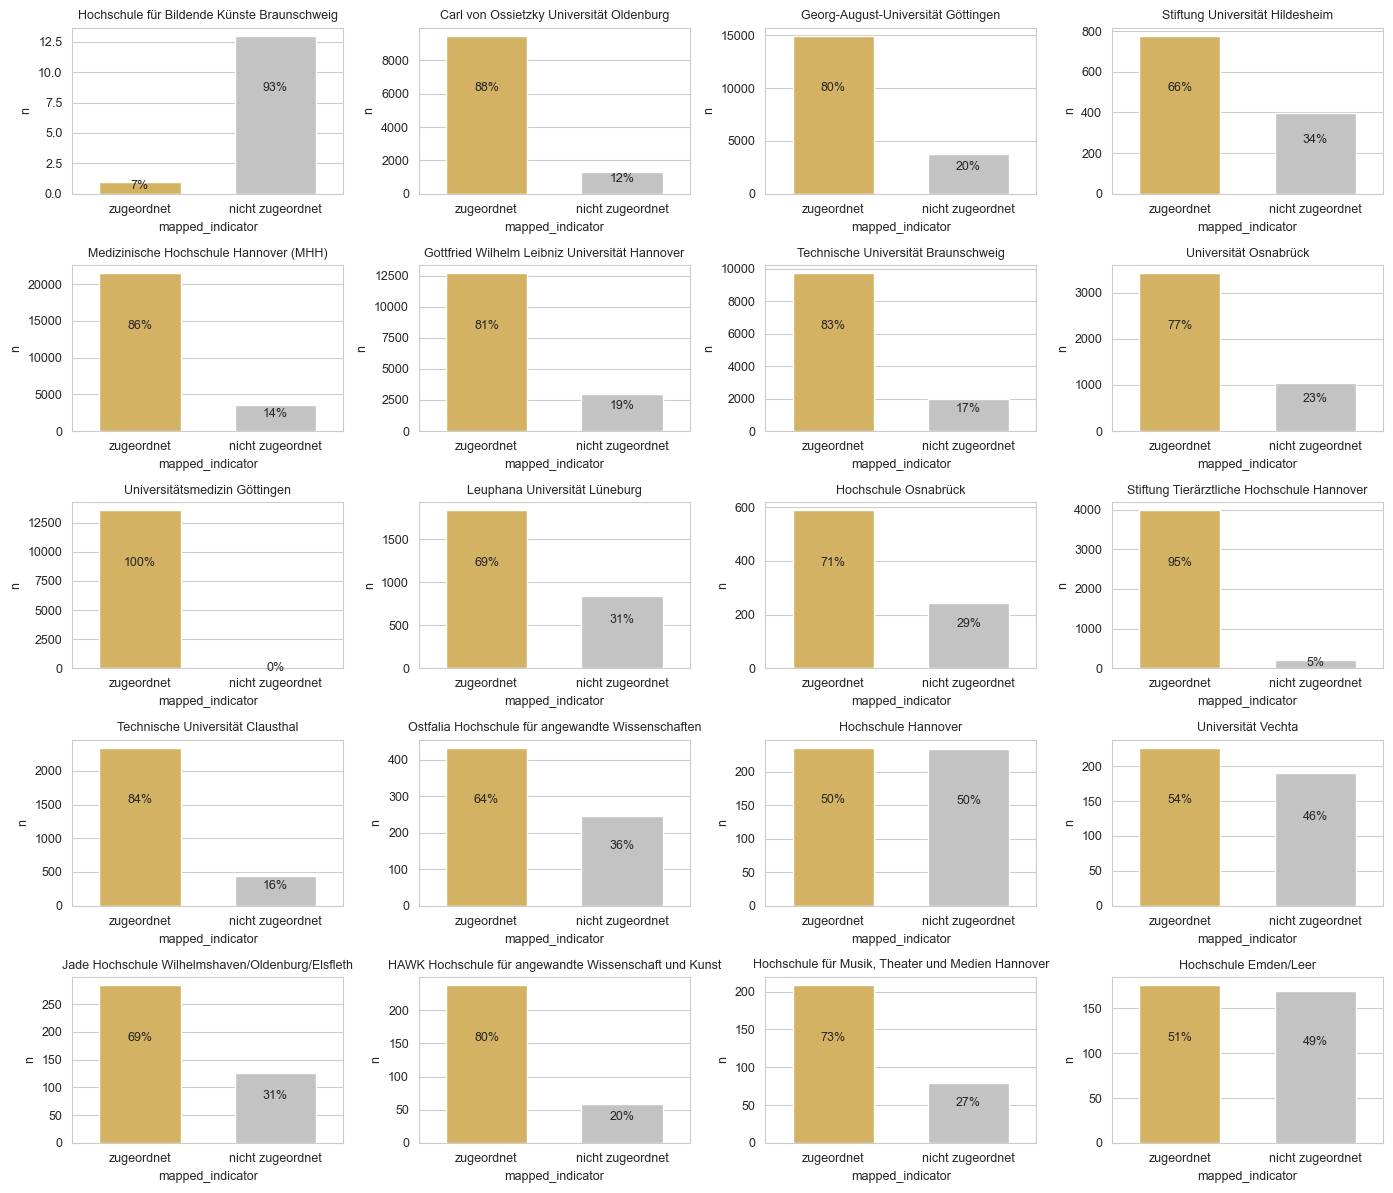

In [33]:
fig, axes = plt.subplots(nrows=5, 
                         ncols=4, 
                         sharex=False, 
                         sharey=False, 
                         figsize=(14,12))

axes = axes.reshape(-1)

for i, ax in enumerate(axes, 0):

    parent_name = liste_aller_hochschulen[i-1]

    df_temp = map_df[map_df.parent_name == parent_name].copy()
    df_temp.fillna('Nicht zugeordnet', inplace=True)

    number_of_items_mapped = df_temp[df_temp.inst_name != 'Nicht zugeordnet'].doi.count()
    number_of_items_not_mapped = df_temp[df_temp.inst_name == 'Nicht zugeordnet'].doi.count()

    prop = df_temp[df_temp.inst_name != 'Nicht zugeordnet'].doi.count() / df_temp.doi.count()

    data = {
        'mapped_indicator': ['zugeordnet', 'nicht zugeordnet'],
        'n': [number_of_items_mapped, number_of_items_not_mapped],
        'prop': [format(prop, '.0%'), format(1-prop, '.0%')]
    }
    
    df = pd.DataFrame(data)
    
    sns.barplot(data=df, 
                x='mapped_indicator', 
                y='n', 
                width=0.6,
                hue='mapped_indicator',
                palette=['#E5BA52', '#c3c3c3'],
                ax=ax).set_title(parent_name, fontdict=dict(fontsize=9, fontweight=500))

    for idx, row in df.iterrows():
        ax.text(row['mapped_indicator'], 
                row['n'] / 1.5, 
                row['prop'], 
                verticalalignment='center', 
                horizontalalignment='center', 
                fontdict=dict(fontsize=9, fontweight=500))

plt.tight_layout()

plt.show()

In [34]:
map_df.sample(10)

,parent_name,inst_name,raw_affiliation_string,doi
47073,Gottfried Wilhelm Leibniz Universität Hannover,Fakultät für Maschinenbau,"Leibniz University Hannover, Institute of Auto...",10.1109/tac.2024.3407633
39829,Medizinische Hochschule Hannover (MHH),Institut für Allgemeinmedizin und Palliativmed...,Institut für Allgemeinmedizin und Palliativmed...,10.1016/j.zefq.2021.10.002
37520,Gottfried Wilhelm Leibniz Universität Hannover,Naturwissenschaftliche Fakultät,"Institut für Technische Chemie, Gottfried Wilh...",10.1007/s11666-021-01182-2
54490,Gottfried Wilhelm Leibniz Universität Hannover,Naturwissenschaftliche Fakultät,Institute of Physical Chemistry and Electroche...,10.1016/j.solmat.2021.111349
33872,Gottfried Wilhelm Leibniz Universität Hannover,Fakultät für Maschinenbau,Institute of Production Engineering and Machin...,10.3390/jmmp5030090
11998,Medizinische Hochschule Hannover (MHH),"Zentrum Augenheilkunde, Hals-Nasen-Ohrenheilku...",Department of Otolaryngology Hannover Medical ...,10.1002/lary.30151
91367,Technische Universität Braunschweig,"Fakultät für Elektrotechnik, Informationstechn...",Institut für Physik der Kondensierten Materie ...,10.1016/j.apsusc.2020.148021
47221,Technische Universität Braunschweig,"Fakultät für Elektrotechnik, Informationstechn...","Technical University of Braunschweig,Institute...",10.1109/imbioc52515.2022.9790275
105735,Universität Osnabrück,Fachbereich Biologie / Chemie,"University of Osnabrück, Center of Cellular Na...",10.1016/j.jbc.2023.104712
16363,Universität Osnabrück,Fachbereich Biologie / Chemie,"Biology Didactics, Department of Biology/Chemi...",10.3389/frym.2023.1055909
